In [2]:
import numpy as np
import pandas as pd
import pickle
import deepchem as dc
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdMolDescriptors 
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors
from rdkit import DataStructs
import selfies as sf
from statistics import mean
from statistics import stdev
import tensorflow as tf
from tensorflow.python.eager import polymorphic_function
polymorphic_function.reduce_retracing = True

# Check versions of DeepChem and RDKit
dc_version = dc.__version__
rk_version = Chem.rdBase.rdkitVersion
print(f"DeepChem version: {dc_version}, RDKit version: {rk_version}")

# Suppress DeepChem warnings regarding missing dependencies
import warnings
warnings.filterwarnings("ignore", message="Skipped loading modules with pytorch-geometric dependency")
warnings.filterwarnings("ignore", message="Skipped loading modules with pytorch-lightning dependency")
warnings.filterwarnings("ignore", message="Skipped loading some Jax models")

DeepChem version: 2.8.0, RDKit version: 2022.09.5


In [3]:
ms = pd.read_pickle(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\_aromatic_2025_1925_CClHNOS.pkl")
ms

,Name,Form,Mw,Cas,mz1,mz2,mz3,mz4,mz5,mz6,...,mz594,mz595,mz596,mz597,mz598,mz599,mz600,Filter_Form,SMILES,AtomGroup
216,"Spiro[1-acetyl-6-chloro-2,3-dihydroindol- 3,5'...",C13H11ClN2O2S2,326,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CSC1=NCC2(S1)C(=O)N(C(C)=O)c3ccc(Cl)cc23,CClHNOS
558,"1-(2,5-Dichlorophenyl)-3-(2,2,2-trichloro-1-he...",C15H18Cl5N3OS,463,301814-08-4,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCCCCC(=O)NC(NC(=S)Nc1cc(Cl)ccc1Cl)C(Cl)(Cl)Cl,CClHNOS
934,"1-(6-Chloro-2-thioxo-2,3-dihydrobenzo[d][1,3]o...",C11H10ClNO2S,255,31315-64-7,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCCC(=O)N1C(=S)Oc2cc(Cl)ccc12,CClHNOS
943,"1-(2,2,2-Trichloro-1-isobutyramidoethyl)-3-(2,...",C13H13Cl6N3OS,469,302953-95-3,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CC(C)C(=O)NC(NC(=S)Nc1c(Cl)cc(Cl)cc1Cl)C(Cl)(C...,CClHNOS
1318,"1,2,4-Triazolidine-3-thione, 1,4-diacetyl-5-(2...",C12H11Cl2N3O2S,331,299918-82-4,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CC(=O)N1NC(=S)N(C1c2ccc(Cl)cc2Cl)C(C)=O,CClHNOS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182172,3-Methoxycarbonylmethylamino-2-(4-chlorophenyl...,C20H25ClN2O4S,424,164595-37-3,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCOC(=O)C1CCN(CC1)C(=S)C(=C/NCC(=O)OC)/c2ccc(C...,CClHNOS
182316,"Acetic acid, ((4-chloro-2,1,3-benzothiadiazol-...",C10H9ClN2O3S,272,29123-12-4,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCOC(=O)COc1ccc2snnc2c1Cl,CClHNOS
182324,"Pyrimidine-5-carboxylic acid, 4,6-dichloro-2-(...",C8H8Cl2N2O2S,266,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCOC(=O)c1c(Cl)nc(SC)nc1Cl,CClHNOS
182327,"Carbonodithioic acid, o-ethyl S-(2,3,6-trichlo...",C9H5Cl3N2OS2,326,212396-23-1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCOC(=S)Sc1c(Cl)c(Cl)nc(Cl)c1C#N,CClHNOS


In [4]:
import deepchem as dc
import selfies as sf
import pandas as pd

# Assuming ms is your DataFrame
X = ms.iloc[:, 4:604]     # spectra
y = ms.iloc[:, 605]       # smiles

se = []
dr = []  # list of indices to drop
c = 0

# Check all SMILES and filter out invalid/unsupported ones
for i in y:
    try:
        selfies_str = sf.encoder(i)
        se.append(selfies_str)
        if '.' in selfies_str:  # check for multi-molecule SMILES
            dr.append(c)
    except Exception as e:
        # Add to drop list if encoding fails (chemically invalid SMILES)
        dr.append(c)
    c += 1

# Drop problematic rows from original DataFrame
ms_cleaned = ms.drop(index=ms.index[dr]).reset_index(drop=True)

# Extract cleaned spectra and SMILES
X_clean = ms_cleaned.iloc[:, 4:604].to_numpy()
y_clean = ms_cleaned.iloc[:, 605].to_numpy()

# Create DeepChem dataset
ds = dc.data.DiskDataset.from_numpy(X_clean, y_clean)
ds

<DiskDataset X.shape: (np.int64(1925), np.int64(600)), y.shape: (np.int64(1925),), w.shape: (np.int64(1925),), task_names: [0]>

In [5]:
# Make a dictionary of all 'SELFIES' parts in the dataset

dataset = se
alphabet = sf.get_alphabet_from_selfies(dataset)
alphabet.add('[nop]')  # '[nop]' is a special padding symbol
alphabet = list(sorted(alphabet))
pad_to_len = max(sf.len_selfies(s) for s in dataset)
symbol_to_idx = {s: i for i, s in enumerate(alphabet)}
symbol_to_idx

{'[#Branch1]': 0,
 '[#Branch2]': 1,
 '[#C]': 2,
 '[#N]': 3,
 '[/-Ring1]': 4,
 '[/C]': 5,
 '[/Cl]': 6,
 '[/N]': 7,
 '[/O]': 8,
 '[=Branch1]': 9,
 '[=Branch2]': 10,
 '[=C]': 11,
 '[=N+1]': 12,
 '[=N-1]': 13,
 '[=N]': 14,
 '[=O]': 15,
 '[=Ring1]': 16,
 '[=Ring2]': 17,
 '[=SH0]': 18,
 '[=S]': 19,
 '[Branch1]': 20,
 '[Branch2]': 21,
 '[C@@H1]': 22,
 '[C@H1]': 23,
 '[C]': 24,
 '[Cl]': 25,
 '[N+1]': 26,
 '[NH1]': 27,
 '[N]': 28,
 '[O-1]': 29,
 '[O]': 30,
 '[P]': 31,
 '[Ring1]': 32,
 '[Ring2]': 33,
 '[SH0]': 34,
 '[S]': 35,
 '[\\-Ring1]': 36,
 '[\\C]': 37,
 '[\\N]': 38,
 '[\\O]': 39,
 '[\\S]': 40,
 '[nop]': 41}

In [8]:
# Convert all SELFIES to ONE-HOT-FLAT (one-hot-flat can be used for machine learning)
sf_hot = sf.batch_selfies_to_flat_hot(se, vocab_stoi=symbol_to_idx, pad_to_len=pad_to_len)
# Create deepchem dataset X=spectrum y=SELFIES one-hot-flat
dataset = dc.data.NumpyDataset(X=np.array(ds.X, dtype='float'), y=sf_hot)

In [9]:
import deepchem as dc

seed = 123  
splitter = dc.splits.RandomStratifiedSplitter()

train_dataset, valid_dataset, test_dataset = splitter.train_valid_test_split(
    dataset=dataset,
    frac_train=0.9,
    frac_valid=0,
    frac_test=0.1,
    seed=seed
)

print(f"🔹 Seed used: {seed}")
print(f"📦 Training set size: {len(train_dataset)}")
print(f"📦 Validation set size: {len(valid_dataset)}")
print(f"📦 Test set size: {len(test_dataset)}")


🔹 Seed used: 123
📦 Training set size: 1666
📦 Validation set size: 0
📦 Test set size: 259


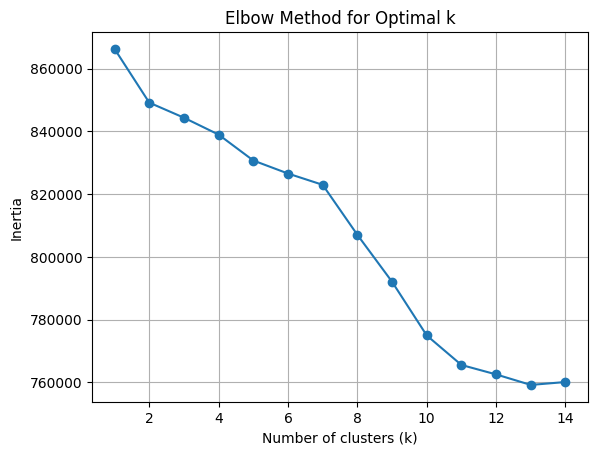

🔍 Elbow point detected at k = 5


In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from kneed import KneeLocator 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_dataset.X)
inertias = []
k_range = range(1, 15)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_train_scaled)
    inertias.append(kmeans.inertia_)
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()
kl = KneeLocator(k_range, inertias, curve='convex', direction='decreasing')
print(f"🔍 Elbow point detected at k = {kl.elbow}")

In [12]:
import os
import pickle
import numpy as np
from sklearn.cluster import KMeans

def train_and_save_kmeans_clusters(X_train, n_clusters=5,
                                   model_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with seed 123\kmeans_model",
                                   cluster_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with  seed 123\clustering_from_trainset"):
    """
    Train KMeans on the training data, save the model, cluster data, and sample indices.

    Parameters:
    - X_train (np.ndarray): Training features
    - n_clusters (int): Number of clusters
    - model_dir (str): Path to save the KMeans model
    - cluster_dir (str): Path to save each cluster's data and indices

    Returns:
    - kmeans (KMeans): Trained model
    - cluster_files (dict): cluster_id -> file path for data and indices
    """
    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(cluster_dir, exist_ok=True)

    # Train KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(X_train)

    # Save model
    model_path = os.path.join(model_dir, "kmeans_model.pkl")
    with open(model_path, "wb") as f:
        pickle.dump(kmeans, f)
    print(f"✅ KMeans model saved to: {model_path}")

    # Save each cluster's data and indices
    cluster_files = {}
    for cluster_id in range(n_clusters):
        indices = np.where(labels == cluster_id)[0]
        cluster_data = X_train[indices]

        data_path = os.path.join(cluster_dir, f"cluster_{cluster_id}.pkl")
        idx_path = os.path.join(cluster_dir, f"cluster_{cluster_id}_indices.npy")

        with open(data_path, "wb") as f:
            pickle.dump(cluster_data, f)
        np.save(idx_path, indices)

        cluster_files[cluster_id] = {
            "data_path": data_path,
            "indices_path": idx_path
        }

        print(f"📁 Cluster {cluster_id} saved: {data_path}")
        print(f"📌 Indices saved: {idx_path}")

    return kmeans, cluster_files
kmeans_model, cluster_paths = train_and_save_kmeans_clusters(train_dataset.X, n_clusters=5)


✅ KMeans model saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with seed 123\kmeans_model\kmeans_model.pkl
📁 Cluster 0 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy
📁 Cluster 1 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\

In [13]:
import pickle

cluster_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with  seed 123\clustering_from_trainset"
clusters = {}

for i in range(5):
    path = f"{cluster_dir}/cluster_{i}.pkl"
    with open(path, "rb") as f:
        clusters[i] = pickle.load(f)

for i in clusters:
    print(f"Cluster {i} shape: {clusters[i].shape}")



Cluster 0 shape: (148, 600)
Cluster 1 shape: (137, 600)
Cluster 2 shape: (309, 600)
Cluster 3 shape: (1021, 600)
Cluster 4 shape: (51, 600)


✅ KMeans model saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with seed 123\kmeans_model\kmeans_model.pkl
📁 Cluster 0 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy
📁 Cluster 1 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\

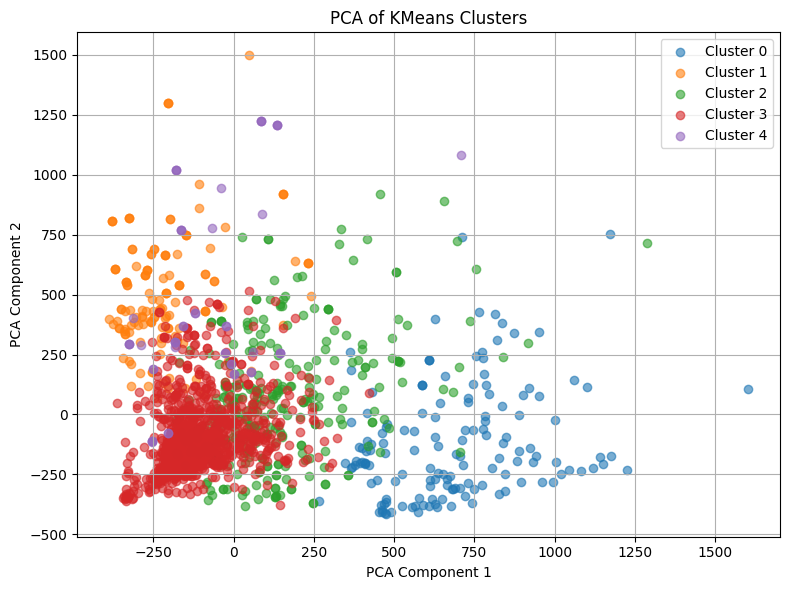

In [14]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_clusters_pca(X, labels, title="PCA of KMeans Clusters"):
    """
    Plots clustered instances using PCA to reduce to 2D.

    Parameters:
    - X (np.ndarray): The input data (e.g., from train_dataset.X)
    - labels (np.ndarray): Cluster labels assigned by KMeans
    - title (str): Title for the plot
    """
    # Perform PCA
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(X)

    # Plot clusters
    plt.figure(figsize=(8, 6))
    unique_labels = np.unique(labels)
    for cluster_id in unique_labels:
        idx = labels == cluster_id
        plt.scatter(reduced[idx, 0], reduced[idx, 1], label=f"Cluster {cluster_id}", alpha=0.6)

    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
kmeans_model, _ = train_and_save_kmeans_clusters(train_dataset.X, n_clusters=5)
labels = kmeans_model.predict(train_dataset.X)

# Plot clusters
plot_clusters_pca(train_dataset.X, labels)


In [15]:
import pickle
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with seed 123\kmeans_model\kmeans_model.pkl", "rb") as f:
    kmeans_model = pickle.load(f)

In [16]:


import os
import pickle
import numpy as np

def assign_and_save_clusters(X, kmeans_model, output_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with  Splitting  with seed 123\clustering_from_testset", dataset_label="test"):
    """
    Applies a trained KMeans model to a new dataset (e.g., test or validation),
    saves each cluster's data and sample indices.

    Parameters:
    - X (np.ndarray): Feature matrix (e.g., test_dataset.X)
    - kmeans_model (KMeans): Trained KMeans model
    - output_dir (str): Directory to save clustered data
    - dataset_label (str): Label for logging (e.g., "test" or "valid")
    """
    os.makedirs(output_dir, exist_ok=True)

    # Predict cluster labels
    cluster_labels = kmeans_model.predict(X)

    # For each cluster, save data and indices
    for cluster_id in np.unique(cluster_labels):
        indices = np.where(cluster_labels == cluster_id)[0]
        cluster_data = X[indices]

        # Save cluster data
        data_path = os.path.join(output_dir, f"cluster_{cluster_id}.pkl")
        with open(data_path, "wb") as f:
            pickle.dump(cluster_data, f)

        # Save indices
        idx_path = os.path.join(output_dir, f"cluster_{cluster_id}_indices.npy")
        np.save(idx_path, indices)

        print(f"✅ Saved {dataset_label} cluster {cluster_id} to: {data_path}")
        print(f"📌 Indices saved to: {idx_path}")

    return cluster_labels
test_X = test_dataset.X 
test_clusters = assign_and_save_clusters(test_X, kmeans_model, output_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with  Splitting  with seed 123\clustering_from_testset", dataset_label="test")





✅ Saved test cluster 0 to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0.pkl
📌 Indices saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0_indices.npy
✅ Saved test cluster 1 to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1.pkl
📌 Indices saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with  Splitting  with seed 123\clustering_from_testset\clus

Cluster 0: size = 24, shape = (24, 600)
Cluster 1: size = 24, shape = (24, 600)
Cluster 2: size = 46, shape = (46, 600)
Cluster 3: size = 156, shape = (156, 600)
Cluster 4: size = 9, shape = (9, 600)


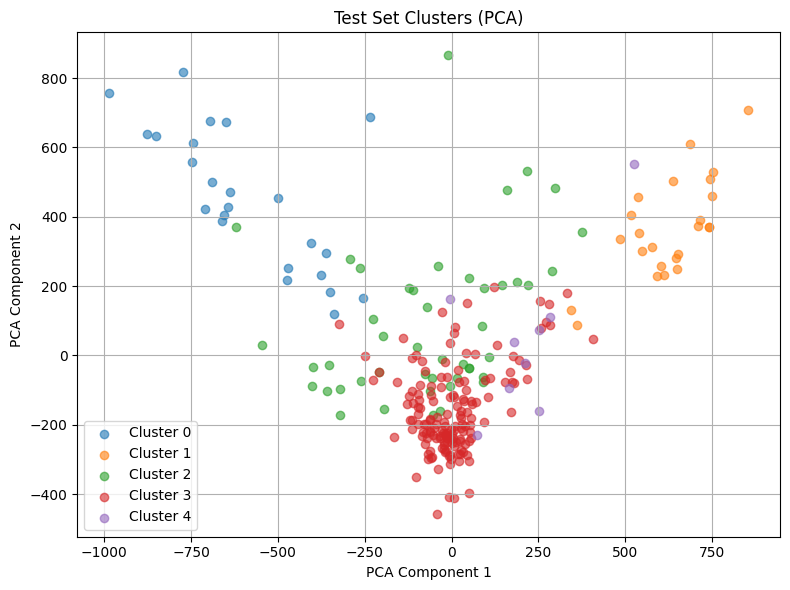

In [17]:

import pickle
import os

Test_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with  Splitting  with seed 123\clustering_from_testset"
Test_clusters = {}

# Load clusters from pickle files
for i in range(5):  
    path = os.path.join(Test_dir, f"cluster_{i}.pkl")
    with open(path, "rb") as f:
        Test_clusters[i] = pickle.load(f)

# Print the size and shape of each cluster
for cluster_id, data in Test_clusters.items():
    print(f"Cluster {cluster_id}: size = {len(data)}, shape = {data.shape}")


plot_clusters_pca(test_X, test_clusters, title="Test Set Clusters (PCA)")


Epoch 1/100 - Loss: 1.081387
Epoch 2/100 - Loss: 0.064466
Epoch 3/100 - Loss: 0.053435
Epoch 4/100 - Loss: 0.041625
Epoch 5/100 - Loss: 0.034874
Epoch 6/100 - Loss: 0.033140
Epoch 7/100 - Loss: 0.032073
Epoch 8/100 - Loss: 0.030740
Epoch 9/100 - Loss: 0.029618
Epoch 10/100 - Loss: 0.028914
Epoch 11/100 - Loss: 0.028080
Epoch 12/100 - Loss: 0.027330
Epoch 13/100 - Loss: 0.026415
Epoch 14/100 - Loss: 0.025634
Epoch 15/100 - Loss: 0.025065
Epoch 16/100 - Loss: 0.024381
Epoch 17/100 - Loss: 0.023569
Epoch 18/100 - Loss: 0.022819
Epoch 19/100 - Loss: 0.021906
Epoch 20/100 - Loss: 0.021167
Epoch 21/100 - Loss: 0.020289
Epoch 22/100 - Loss: 0.019473
Epoch 23/100 - Loss: 0.018782
Epoch 24/100 - Loss: 0.017904
Epoch 25/100 - Loss: 0.017071
Epoch 26/100 - Loss: 0.016602
Epoch 27/100 - Loss: 0.015635
Epoch 28/100 - Loss: 0.014796
Epoch 29/100 - Loss: 0.013997
Epoch 30/100 - Loss: 0.013374
Epoch 31/100 - Loss: 0.012729
Epoch 32/100 - Loss: 0.012192
Epoch 33/100 - Loss: 0.011307
Epoch 34/100 - Loss

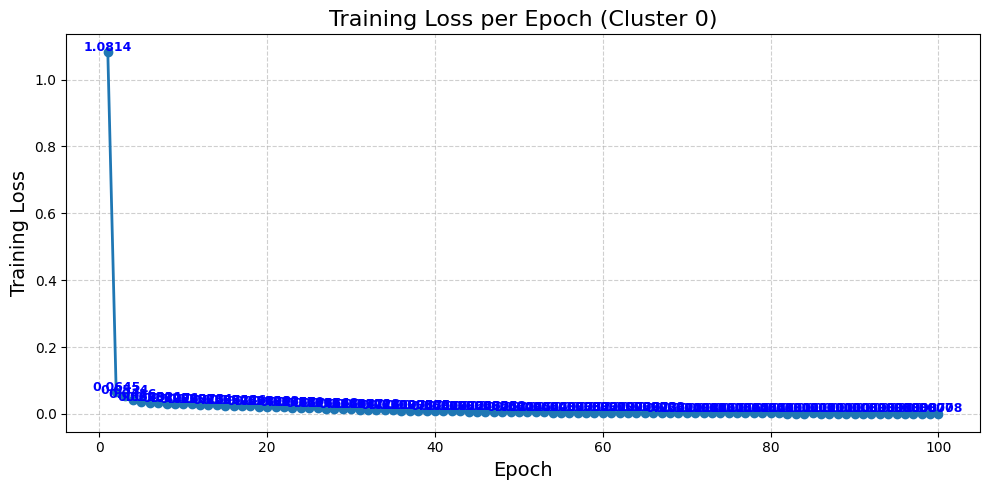

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with  seed 123\models_\model0000


In [18]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 0 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl", "rb") as f:
    X_cluster0 = pickle.load(f)

cluster_0_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy")
y_cluster0 = train_dataset.y[cluster_0_indices]

# Ensure y is 2D
if len(y_cluster0.shape) == 1:
    y_cluster0 = y_cluster0.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_0 = dc.data.NumpyDataset(X=np.array(X_cluster0), y=np.array(y_cluster0))

# === Model config
n_tasks = train_dataset_0.y.shape[1]
n_features = train_dataset_0.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_0 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with  seed 123\models_\model0000"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_0.fit(train_dataset_0, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 0)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_0.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [ ]:
import pickle
import numpy as np

# === Load cluster 0 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0.pkl", "rb") as f:
    X_test_cluster0 = pickle.load(f)

# === Load corresponding indices
test_cluster_0_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0_indices.npy")

y_test_cluster0 = test_dataset.y[test_cluster_0_indices]

if len(y_test_cluster0.shape) == 1:
    y_test_cluster0 = y_test_cluster0.reshape(-1, 1)


In [20]:

import deepchem as dc
test_dataset_0 = dc.data.NumpyDataset(X=np.array(X_test_cluster0), y=np.array(y_test_cluster0))

test_dataset_0 = dc.data.NumpyDataset(X=np.array(X_test_cluster0), y=np.array(y_test_cluster0))

predictions_0 = model_0.predict(test_dataset_0)

print("✅ Prediction shape:", predictions_0.shape)
print("Example prediction:", predictions_0[0])



✅ Prediction shape: (24, 2898, 2)
Example prediction: [[1.0000000e+00 1.0482679e-13]
 [1.0000000e+00 1.7693703e-18]
 [1.0000000e+00 2.5380968e-17]
 ...
 [1.0000000e+00 5.0815727e-17]
 [1.0000000e+00 6.4298453e-15]
 [8.8837358e-17 1.0000000e+00]]


In [21]:
itos={}
c=0
for i in symbol_to_idx:
  itos[c]=i
  c=c+1
itos
from rdkit import Chem, DataStructs
import numpy as np


In [22]:

def evaluate_flat_predictions(predictions, test_dataset, itos, sf, cutoff=0.5):
    """
    Evaluate SELFIES predictions from flat one-hot output format.
    Args:
        predictions: model outputs (shape: [num_samples, sequence_len * vocab_size])
        test_dataset: DeepChem test dataset
        itos: index-to-symbol mapping (dict or list)
        sf: selfies module (with decoder)
        cutoff: threshold for class activation

    Returns:
        Prints evaluation stats and decoded examples
    """
    if isinstance(itos, list):
        itos = {i: tok for i, tok in enumerate(itos)}

    vocab_size = len(itos)
    total = len(test_dataset)
    hit = 0
    tanimoto_scores = []

    for idx in range(total):
        flat_pred = predictions[idx]
        binary_pred = [1 if val[1] >= cutoff else 0 for val in flat_pred]  

        num_tokens = len(binary_pred) // vocab_size
        selfie_str = ''
        for i in range(num_tokens):
            for j in range(vocab_size):
                if binary_pred[i * vocab_size + j] == 1 and itos[j] != '[nop]':
                    selfie_str += itos[j]

        try:
            pred_smiles = sf.decoder(selfie_str)
        except:
            pred_smiles = ''

        ground_truth_flat = test_dataset.y[idx]
        true_indices = np.argmax(ground_truth_flat.reshape(-1, vocab_size), axis=1)
        true_selfie = ''.join([itos.get(i, '') for i in true_indices])
        try:
            true_smiles = sf.decoder(true_selfie)
        except:
            true_smiles = ''

        # RDKit comparison
        mol_pred = Chem.MolFromSmiles(pred_smiles)
        mol_true = Chem.MolFromSmiles(true_smiles)
        if mol_pred is None or mol_true is None:
            tanimoto = 0.0
        else:
            fp_pred = Chem.RDKFingerprint(mol_pred)
            fp_true = Chem.RDKFingerprint(mol_true)
            tanimoto = DataStructs.FingerprintSimilarity(fp_pred, fp_true)

        tanimoto_scores.append(tanimoto)
        if pred_smiles == true_smiles:
            hit += 1

        print(f"[{idx}] Pred: {pred_smiles} | True: {true_smiles} | Tanimoto: {tanimoto:.3f}")

    # Summary
    tanimoto_scores = np.array(tanimoto_scores)
    print("\n📊 Evaluation Summary:")
    print(f"✅ Exact SMILES match: {hit}/{total} ({100*hit/total:.1f}%)")
    print(f"Tanimoto >= 1.0: {np.sum(tanimoto_scores == 1.0)}")
    print(f"Tanimoto >= 0.9: {np.sum(tanimoto_scores >= 0.9)}")
    print(f"Tanimoto >= 0.6: {np.sum(tanimoto_scores >= 0.6)}")
    print(f"Avg Tanimoto: {tanimoto_scores.mean():.3f}")


In [23]:
evaluate_flat_predictions(predictions_0, test_dataset_0, itos, sf, cutoff=0.5)


[0] Pred: ClC1=CC=CC=C1C(=O)NNC(=S)NC2=CC=CC=C2 | True: ClC1=CC=CC=C1C(=O)NNC(=S)NC2=CC=CC=C2 | Tanimoto: 1.000
[1] Pred: CCCC=CCCl | True: CC(SC1=NC(N)=CC(O)=N1)C2=CC=CC=C2Cl | Tanimoto: 0.007
[2] Pred: ClC1=CC=C(C=C1)[SH0](=O)(=O)CC | True: Cl[C@@H1](CN[SH0](=O)(=O)C1=CC=C(Cl)C=C1)C#N | Tanimoto: 0.327
[3] Pred: ClC=CC=CCCNCCC | True: NNC(=O)CCN[SH0](=O)(=O)C1=CC=C(Cl)C=C1 | Tanimoto: 0.035
[4] Pred: ClC=CC=CCCCCCC | True: OC(=O)CC(NC(=O)C=1SC=CC=1)C2=CC=C(Cl)C=C2 | Tanimoto: 0.032
[5] Pred: ClC=CC=CNC(C)CCC(C)C | True: ClC1=CC=C(NC(=S)C=2OC=CC=2)C=C1 | Tanimoto: 0.065
[6] Pred: ClCCC(C)CCCCCC=C | True: ClC1=CN=C(OC2=CC=C(OC(=O)C=3SC=CC=3)C=C2)C(Cl)=C1 | Tanimoto: 0.030
[7] Pred: ClCC=O | True: ClC1=CC=C(C(Cl)=C1)C2=NN=C3SC(=NN23)C=4OC=CC=4 | Tanimoto: 0.005
[8] Pred: ClC=C1C=CCC=C1C(=O)NC(=S)C=CC=C=C | True: ClC1=CC=C(C=C1)[SH0](=O)(=O)C(=CC=2SC=CC=2)C#N | Tanimoto: 0.155
[9] Pred: ClC1=CC=C(C=C1)C(=O)NCC=SSCN=CC2=CC=CC=C2N=O | True: ClC1=CC=CC=C1NCN2C(=O)SC(=C/C3=CC=CC=C3)/C2=O | T

Epoch 1/100 - Loss: 1.052199
Epoch 2/100 - Loss: 0.064566
Epoch 3/100 - Loss: 0.055473
Epoch 4/100 - Loss: 0.040065
Epoch 5/100 - Loss: 0.034168
Epoch 6/100 - Loss: 0.032545
Epoch 7/100 - Loss: 0.030721
Epoch 8/100 - Loss: 0.028980
Epoch 9/100 - Loss: 0.027703
Epoch 10/100 - Loss: 0.026594
Epoch 11/100 - Loss: 0.025474
Epoch 12/100 - Loss: 0.024105
Epoch 13/100 - Loss: 0.022901
Epoch 14/100 - Loss: 0.021691
Epoch 15/100 - Loss: 0.020416
Epoch 16/100 - Loss: 0.019188
Epoch 17/100 - Loss: 0.017666
Epoch 18/100 - Loss: 0.016659
Epoch 19/100 - Loss: 0.015346
Epoch 20/100 - Loss: 0.014220
Epoch 21/100 - Loss: 0.013090
Epoch 22/100 - Loss: 0.011861
Epoch 23/100 - Loss: 0.010820
Epoch 24/100 - Loss: 0.009903
Epoch 25/100 - Loss: 0.009483
Epoch 26/100 - Loss: 0.008611
Epoch 27/100 - Loss: 0.007912
Epoch 28/100 - Loss: 0.007367
Epoch 29/100 - Loss: 0.006350
Epoch 30/100 - Loss: 0.006072
Epoch 31/100 - Loss: 0.005412
Epoch 32/100 - Loss: 0.004999
Epoch 33/100 - Loss: 0.004455
Epoch 34/100 - Loss

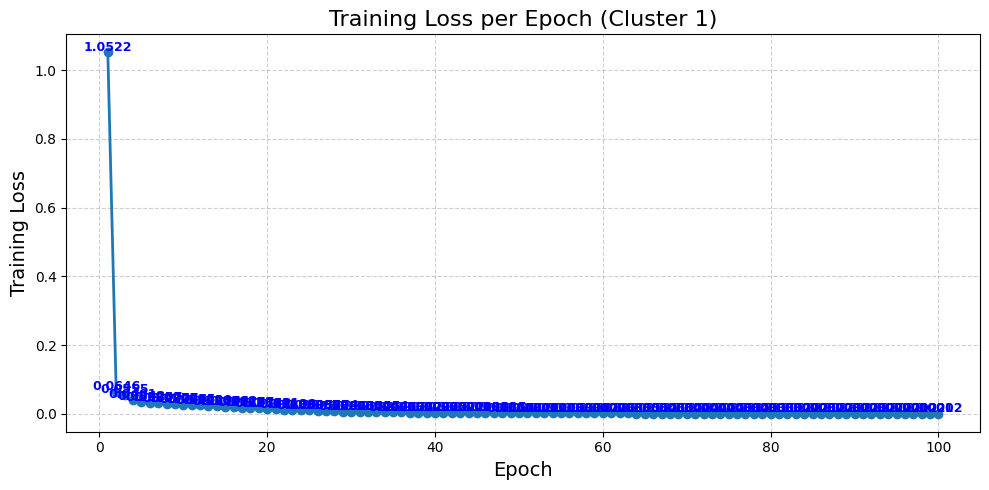

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with seed 123\models_\model1111


In [24]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 1 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl", "rb") as f:
    X_cluster1 = pickle.load(f)

cluster_1_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with  seed 123\clustering_from_trainset\cluster_1_indices.npy")
y_cluster1 = train_dataset.y[cluster_1_indices]

# Ensure y is 2D
if len(y_cluster1.shape) == 1:
    y_cluster1 = y_cluster1.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_1 = dc.data.NumpyDataset(X=np.array(X_cluster1), y=np.array(y_cluster1))

# === Model config
n_tasks = train_dataset_1.y.shape[1]
n_features = train_dataset_1.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_1 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with seed 123\models_\model1111"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_1.fit(train_dataset_1, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 1)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_1.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)



In [25]:
import pickle
import numpy as np
import deepchem as dc

# === Load cluster 1 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1.pkl", "rb") as f:
    X_test_cluster1 = pickle.load(f)

# === Load corresponding indices
test_cluster_1_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster1 = test_dataset.y[test_cluster_1_indices]

if len(y_test_cluster1.shape) == 1:
    y_test_cluster1 = y_test_cluster1.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 1
test_dataset_1 = dc.data.NumpyDataset(X=np.array(X_test_cluster1), y=np.array(y_test_cluster1))

# === Predict using the trained model_1
predictions_1 = model_1.predict(test_dataset_1)

# === Inspect prediction shape 
print("✅ Prediction shape:", predictions_1.shape)
print("Example prediction:", predictions_1[0])
evaluate_flat_predictions(predictions_1, test_dataset_1, itos, sf, cutoff=0.5)


✅ Prediction shape: (24, 2898, 2)
Example prediction: [[1.0000000e+00 8.0573531e-13]
 [1.0000000e+00 2.4938603e-11]
 [1.0000000e+00 1.5545870e-11]
 ...
 [1.0000000e+00 1.3381812e-11]
 [1.0000000e+00 3.9504064e-13]
 [7.5152051e-10 1.0000000e+00]]
[0] Pred: CSC1=NCC2(S1)C(=O)N(C(C)=O)C3=CC=C(Cl)C=C23 | True: CSC1=NCC2(S1)C(=O)N(C(C)=O)C3=CC=C(Cl)C=C23 | Tanimoto: 1.000
[1] Pred: CC(=O)C=1N=C(SC=1Cl)C2=CC=CC=C2 | True: CC(=O)C=1N=C(SC=1Cl)C2=CC=CC=C2 | Tanimoto: 1.000
[2] Pred: CC(=O)NC1=CC=C(C=C1)[SH0](=O)(=O)C2=CC=NC3=CC(Cl)=CC=C23 | True: CC(=O)NC1=CC=C(C=C1)[SH0](=O)(=O)C2=CC=NC3=CC(Cl)=CC=C23 | Tanimoto: 1.000
[3] Pred: CCCCCC(=O)NC(NC(=S)NC1=CC=C(Cl)C=C1Cl)C(Cl)(Cl)Cl | True: CCCCCC(=O)NC(NC(=S)NC1=CC=C(Cl)C=C1Cl)C(Cl)(Cl)Cl | Tanimoto: 1.000
[4] Pred: CCOC(C)C=CSCCCC | True: CCOC(=O)C=1C=2CCCCC=2SC=1N(Cl)N=CC(C)=O | Tanimoto: 0.052
[5] Pred: CCS(N)=O | True: CC(=O)NC1=CC=C(SC2=C(Cl)C(C)=NC(C)=C2Cl)C=C1 | Tanimoto: 0.009
[6] Pred: C=1CON=C(C=CC#CC=1CN)CSC=C=N | True: CC(=O)CC1=NSC(N

Epoch 1/100 - Loss: 0.622428
Epoch 2/100 - Loss: 0.069822
Epoch 3/100 - Loss: 0.042100
Epoch 4/100 - Loss: 0.037222
Epoch 5/100 - Loss: 0.034803
Epoch 6/100 - Loss: 0.033246
Epoch 7/100 - Loss: 0.032180
Epoch 8/100 - Loss: 0.031309
Epoch 9/100 - Loss: 0.030359
Epoch 10/100 - Loss: 0.029423
Epoch 11/100 - Loss: 0.028451
Epoch 12/100 - Loss: 0.027270
Epoch 13/100 - Loss: 0.026031
Epoch 14/100 - Loss: 0.024791
Epoch 15/100 - Loss: 0.023410
Epoch 16/100 - Loss: 0.021953
Epoch 17/100 - Loss: 0.020696
Epoch 18/100 - Loss: 0.019338
Epoch 19/100 - Loss: 0.018094
Epoch 20/100 - Loss: 0.017082
Epoch 21/100 - Loss: 0.016636
Epoch 22/100 - Loss: 0.015501
Epoch 23/100 - Loss: 0.014357
Epoch 24/100 - Loss: 0.012911
Epoch 25/100 - Loss: 0.011578
Epoch 26/100 - Loss: 0.010781
Epoch 27/100 - Loss: 0.009639
Epoch 28/100 - Loss: 0.009042
Epoch 29/100 - Loss: 0.008325
Epoch 30/100 - Loss: 0.007654
Epoch 31/100 - Loss: 0.006920
Epoch 32/100 - Loss: 0.006434
Epoch 33/100 - Loss: 0.005910
Epoch 34/100 - Loss

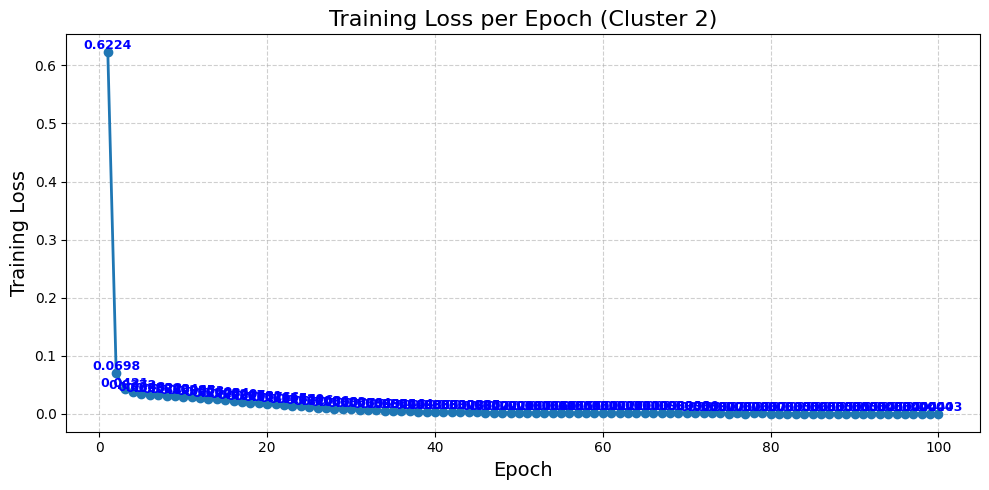

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with seed 123\models_\model2222


In [26]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 2 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with  seed 123\clustering_from_trainset\cluster_2.pkl", "rb") as f:
    X_cluster2 = pickle.load(f)

cluster_2_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with  seed 123\clustering_from_trainset\cluster_2_indices.npy")
y_cluster2 = train_dataset.y[cluster_2_indices]

if len(y_cluster2.shape) == 1:
    y_cluster2 = y_cluster2.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_2 = dc.data.NumpyDataset(X=np.array(X_cluster2), y=np.array(y_cluster2))

# === Model config
n_tasks = train_dataset_2.y.shape[1]
n_features = train_dataset_2.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_2 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with seed 123\models_\model2222"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_2.fit(train_dataset_2, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 2)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_2.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [27]:
# === Load cluster 2 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_2.pkl", "rb") as f:
    X_test_cluster2 = pickle.load(f)

# === Load corresponding indices
test_cluster_2_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_2_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster2 = test_dataset.y[test_cluster_2_indices]

if len(y_test_cluster2.shape) == 1:
    y_test_cluster2 = y_test_cluster2.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 2
test_dataset_2 = dc.data.NumpyDataset(X=np.array(X_test_cluster2), y=np.array(y_test_cluster2))

# === Predict using the trained model_2
predictions_2 = model_2.predict(test_dataset_2)

# === Inspect prediction shape 
print("✅ Prediction shape:", predictions_2.shape)
print("Example prediction:", predictions_2[0])

evaluate_flat_predictions(predictions_2, test_dataset_2, itos, sf, cutoff=0.5)


✅ Prediction shape: (46, 2898, 2)
Example prediction: [[1.0000000e+00 4.7763606e-11]
 [1.0000000e+00 8.9324970e-10]
 [1.0000000e+00 3.1210154e-12]
 ...
 [1.0000000e+00 4.4690386e-15]
 [1.0000000e+00 5.3894352e-15]
 [1.4057756e-12 1.0000000e+00]]
[0] Pred: CC[SH0](=O)(=O)CC(C)(Cl)C(=O)NC1=CC=C(C=C1)C(=O)OC | True: CC[SH0](=O)(=O)CC(C)(Cl)C(=O)NC1=CC=C(C=C1)C(=O)OC | Tanimoto: 1.000
[1] Pred: CC1=NC2=CC=CC=C2C(=O)N1NC(=O)C=3SC4=CC=CC=C4C=3Cl | True: CC1=NC2=CC=CC=C2C(=O)N1NC(=O)C=3SC4=CC=CC=C4C=3Cl | Tanimoto: 1.000
[2] Pred: C1C=CC=C1C | True: CC1=CC(SCC=2OC(=NN=2)C3=CC=C(C(C)=C3)[N+1]([O-1])=O)=C(C)C=C1Cl | Tanimoto: 0.020
[3] Pred: ClC1=CC=CC=C1NN=C(C#N)[SH0](=O)(=O)C2=CC=CC=N2 | True: ClC1=CC=CC=C1NN=C(C#N)[SH0](=O)(=O)C2=CC=CC=N2 | Tanimoto: 1.000
[4] Pred: ClC1=CC=C(C=C1)N2C(=O)C(=O)N(C3=CC=CN=C3)C2=S | True: ClC1=CC=C(C=C1)N2C(=O)C(=O)N(C3=CC=CN=C3)C2=S | Tanimoto: 1.000
[5] Pred: ClC1=CN2SC(=NC(=O)C3=CC=CC=C3)N=C2C=C1 | True: ClC1=CN2SC(=NC(=O)C3=CC=CC=C3)N=C2C=C1 | Tanimoto: 1.0

Epoch 1/100 - Loss: 0.244523
Epoch 2/100 - Loss: 0.044745
Epoch 3/100 - Loss: 0.041082
Epoch 4/100 - Loss: 0.039428
Epoch 5/100 - Loss: 0.037915
Epoch 6/100 - Loss: 0.036229
Epoch 7/100 - Loss: 0.034411
Epoch 8/100 - Loss: 0.032751
Epoch 9/100 - Loss: 0.031113
Epoch 10/100 - Loss: 0.029347
Epoch 11/100 - Loss: 0.027672
Epoch 12/100 - Loss: 0.026094
Epoch 13/100 - Loss: 0.024569
Epoch 14/100 - Loss: 0.022936
Epoch 15/100 - Loss: 0.021420
Epoch 16/100 - Loss: 0.019987
Epoch 17/100 - Loss: 0.018704
Epoch 18/100 - Loss: 0.017389
Epoch 19/100 - Loss: 0.015829
Epoch 20/100 - Loss: 0.015216
Epoch 21/100 - Loss: 0.013932
Epoch 22/100 - Loss: 0.013137
Epoch 23/100 - Loss: 0.012175
Epoch 24/100 - Loss: 0.011364
Epoch 25/100 - Loss: 0.010561
Epoch 26/100 - Loss: 0.009794
Epoch 27/100 - Loss: 0.009267
Epoch 28/100 - Loss: 0.008571
Epoch 29/100 - Loss: 0.008293
Epoch 30/100 - Loss: 0.007588
Epoch 31/100 - Loss: 0.007134
Epoch 32/100 - Loss: 0.006870
Epoch 33/100 - Loss: 0.006431
Epoch 34/100 - Loss

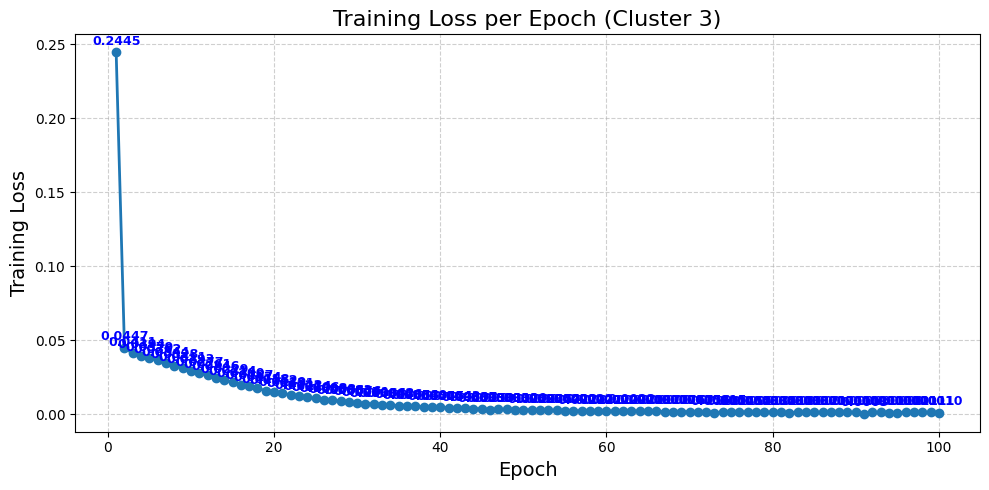

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with seed 123\models_\model3333


In [28]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 3 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with  seed 123\clustering_from_trainset\cluster_3.pkl", "rb") as f:
    X_cluster3 = pickle.load(f)

cluster_3_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with  seed 123\clustering_from_trainset\cluster_3_indices.npy")
y_cluster3 = train_dataset.y[cluster_3_indices]

if len(y_cluster3.shape) == 1:
    y_cluster3 = y_cluster3.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_3 = dc.data.NumpyDataset(X=np.array(X_cluster3), y=np.array(y_cluster3))

# === Model config
n_tasks = train_dataset_3.y.shape[1]
n_features = train_dataset_3.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_3 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with seed 123\models_\model3333"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_3.fit(train_dataset_3, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 3)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_3.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [29]:
# === Load cluster 3 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_3.pkl", "rb") as f:
    X_test_cluster3 = pickle.load(f)

# === Load corresponding indices
test_cluster_3_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_3_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster3 = test_dataset.y[test_cluster_3_indices]

if len(y_test_cluster3.shape) == 1:
    y_test_cluster3 = y_test_cluster3.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 3
test_dataset_3 = dc.data.NumpyDataset(X=np.array(X_test_cluster3), y=np.array(y_test_cluster3))

# === Predict using the trained model_3
predictions_3 = model_3.predict(test_dataset_3)

# === Inspect prediction shape 
print("✅ Prediction shape:", predictions_3.shape)
print("Example prediction:", predictions_3[0])

evaluate_flat_predictions(predictions_3, test_dataset_3, itos, sf, cutoff=0.5)


✅ Prediction shape: (156, 2898, 2)
Example prediction: [[1.0000000e+00 2.5220556e-10]
 [1.0000000e+00 1.0555440e-11]
 [1.0000000e+00 5.4085203e-10]
 ...
 [1.0000000e+00 2.8301158e-11]
 [1.0000000e+00 5.8246088e-09]
 [7.1330973e-13 1.0000000e+00]]
[0] Pred: CC1=C(C(=O)NC(=O)N1)[SH0](Cl)(=O)=O | True: CC1=C(C(=O)NC(=O)N1)[SH0](Cl)(=O)=O | Tanimoto: 1.000
[1] Pred: NC(=O)CCCCl | True: CCNC(=S)NN=CC1=CC(Cl)=CC(Cl)=C1O | Tanimoto: 0.021
[2] Pred: CCCN=C=CSCN=C | True: CN(C)[SH0](=O)(=O)NC1=CC(Cl)=CC=C1Cl | Tanimoto: 0.029
[3] Pred: CC=CCC=CNC(=O)CSCC=C=C | True: N[SH0](=O)(=O)C1=CC2=C(NC(N[SH0]2(=O)=O)C3CC4CC3C=C4)C=C1Cl | Tanimoto: 0.083
[4] Pred: C=1NCS=C2SC=CC(C)=C2[N+1]([O-1])=NN=1 | True: CCN(CC)C(=S)SC1=C(Cl)C(Cl)=NC(Cl)=C1C(=O)OC | Tanimoto: 0.252
[5] Pred: CCCSCNCN=C(O)Cl | True: CN1SC(=C(Cl)C1=O)Cl | Tanimoto: 0.037
[6] Pred: CSCCCC#C | True: CC1SC(NC1=O)C2=CC=C(Cl)C(Cl)=C2 | Tanimoto: 0.029
[7] Pred: CCN(CCCC=CCCC=C1OC=NC2=CC=C(Cl)C=C12)C | True: CCN(CC)CC1=CC(NC2=CC=NC3=CC(Cl)=CC

Epoch 1/100 - Loss: 1.144403
Epoch 2/100 - Loss: 0.152249
Epoch 3/100 - Loss: 0.043087
Epoch 4/100 - Loss: 0.036606
Epoch 5/100 - Loss: 0.032758
Epoch 6/100 - Loss: 0.027778
Epoch 7/100 - Loss: 0.022930
Epoch 8/100 - Loss: 0.019318
Epoch 9/100 - Loss: 0.017519
Epoch 10/100 - Loss: 0.016059
Epoch 11/100 - Loss: 0.014780
Epoch 12/100 - Loss: 0.013684
Epoch 13/100 - Loss: 0.012644
Epoch 14/100 - Loss: 0.011779
Epoch 15/100 - Loss: 0.010669
Epoch 16/100 - Loss: 0.009781
Epoch 17/100 - Loss: 0.009262
Epoch 18/100 - Loss: 0.008329
Epoch 19/100 - Loss: 0.007729
Epoch 20/100 - Loss: 0.007144
Epoch 21/100 - Loss: 0.006408
Epoch 22/100 - Loss: 0.005764
Epoch 23/100 - Loss: 0.005349
Epoch 24/100 - Loss: 0.004770
Epoch 25/100 - Loss: 0.004399
Epoch 26/100 - Loss: 0.004112
Epoch 27/100 - Loss: 0.003598
Epoch 28/100 - Loss: 0.003364
Epoch 29/100 - Loss: 0.003101
Epoch 30/100 - Loss: 0.002654
Epoch 31/100 - Loss: 0.002458
Epoch 32/100 - Loss: 0.002374
Epoch 33/100 - Loss: 0.002140
Epoch 34/100 - Loss

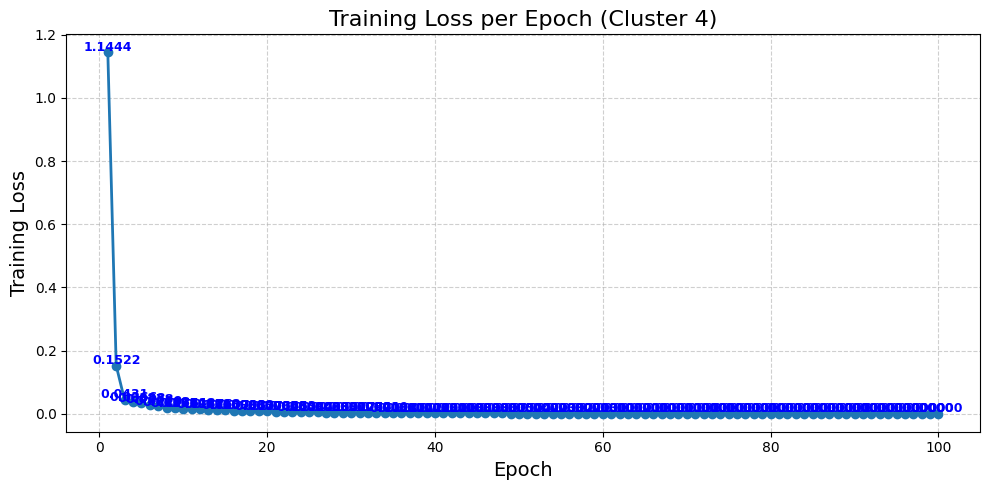

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with seed 123\models_\model4444


In [30]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 4 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with  seed 123\clustering_from_trainset\cluster_4.pkl", "rb") as f:
    X_cluster4 = pickle.load(f)

cluster_4_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with  seed 123\clustering_from_trainset\cluster_4_indices.npy")
y_cluster4 = train_dataset.y[cluster_4_indices]

if len(y_cluster4.shape) == 1:
    y_cluster4 = y_cluster4.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_4 = dc.data.NumpyDataset(X=np.array(X_cluster4), y=np.array(y_cluster4))

# === Model config
n_tasks = train_dataset_4.y.shape[1]
n_features = train_dataset_4.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_4 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with seed 123\models_\model4444"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_4.fit(train_dataset_4, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 4)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_4.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [31]:
# === Load cluster 4 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_4.pkl", "rb") as f:
    X_test_cluster4 = pickle.load(f)

# === Load corresponding indices
test_cluster_4_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1925_CClHNOS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_4_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster4 = test_dataset.y[test_cluster_4_indices]

if len(y_test_cluster4.shape) == 1:
    y_test_cluster4 = y_test_cluster4.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 4
test_dataset_4 = dc.data.NumpyDataset(X=np.array(X_test_cluster4), y=np.array(y_test_cluster4))

# === Predict using the trained model_4
predictions_4 = model_4.predict(test_dataset_4)

# === Inspect prediction shape 
print("✅ Prediction shape:", predictions_4.shape)
print("Example prediction:", predictions_4[0])

evaluate_flat_predictions(predictions_4, test_dataset_4, itos, sf, cutoff=0.5)


✅ Prediction shape: (9, 2898, 2)
Example prediction: [[1.0000000e+00 3.3932671e-13]
 [1.0000000e+00 4.6577842e-15]
 [1.0000000e+00 4.7443343e-12]
 ...
 [1.0000000e+00 1.2828560e-14]
 [1.0000000e+00 3.9098453e-13]
 [5.6695583e-15 1.0000000e+00]]
[0] Pred: CCOC(=O)C1CCN(CC1)C(=S)C(=C/NCC(=O)OC)/C2=CC=C(Cl)C=C2 | True: CCOC(=O)C1CCN(CC1)C(=S)C(=C/NCC(=O)OC)/C2=CC=C(Cl)C=C2 | Tanimoto: 1.000
[1] Pred: CCOC(=O)COC1=CC=C2SN=NC2=C1Cl | True: CCOC(=O)COC1=CC=C2SN=NC2=C1Cl | Tanimoto: 1.000
[2] Pred: CCOC(=S)SC1=C(Cl)C(Cl)=NC(Cl)=C1C#N | True: CCOC(=S)SC1=C(Cl)C(Cl)=NC(Cl)=C1C#N | Tanimoto: 1.000
[3] Pred: CCOC(=O)C(NC(=NC(=S)C1CNCCO1)C2=CC=C(Cl)C=C2)C(=O)OCC | True: CCOC(=O)C(NC(=NC(=S)C1CNCCO1)C2=CC=C(Cl)C=C2)C(=O)OCC | Tanimoto: 1.000
[4] Pred: CCCCC(C)C/N(C)CC(C)CCC | True: COC(=O)CNC=C(C(=S)N1CCCCC1)C2=CC=C(Cl)C=C2 | Tanimoto: 0.092
[5] Pred: CCCCC(C)CCCC=CCC=CCC#C | True: ClC1=CC=C(CC(=S)N2CCOCC2)C=C1 | Tanimoto: 0.044
[6] Pred: CC=CC(C)C1/NCC(CC1C=CC=C2Cl)C=CC2 | True: N[SH0](=O)(=O)C1=C

--------------------------------------------------------------